<a href="https://colab.research.google.com/github/PhungHanh/Xulyanh_PhungThiHanh/blob/main/DemoTieuluancuoiky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kết nối đến Google Drive để lấy ảnh
from google.colab import drive
drive.mount('/content/drive')
# Cài đặt các thư viện xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Hàm cv2_imshow riêng của colab để ảnh hiển thị không bị lỗi
from google.colab.patches import cv2_imshow

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CẤU HÌNH
image_path = "/content/drive/MyDrive/Xulyanh/Phoi_tran_dich.tiff" # Đường dẫn đến file ảnh
# Khai báo các hằng số
MIN_RELATIVE_DIFFERENCE = 0.08
MIN_MEAN_DIFFERENCE = 20.0

def show_step_result(title, img, is_colormap=False):
    """Hàm phụ trợ hiển thị ngay kết quả và Histogram của từng bước xử lý"""
    plt.figure(figsize=(12, 4))

    # Hiển thị ảnh
    plt.subplot(1, 2, 1)
    if is_colormap:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Ảnh: {title}")
    plt.axis('off')

    # Hiển thị Histogram (chỉ dành cho ảnh xám)
    plt.subplot(1, 2, 2)
    if not is_colormap:
        plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)
        plt.title(f"Histogram: {title}")
        plt.xlabel("Mức xám (0 - 255)")
        plt.ylabel("Tần suất pixel")
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        # Nếu là ảnh màu thì không vẽ Histogram đơn sắc, chỉ hiện dòng thông báo
        plt.text(0.5, 0.5, "Bản đồ nhiệt / Ảnh màu BGR\n(Không vẽ Histogram đơn sắc)",
                 ha='center', va='center', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


--- 1. Đã nạp ảnh gốc ---


/tmp/ipykernel_1197/2981732479.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)


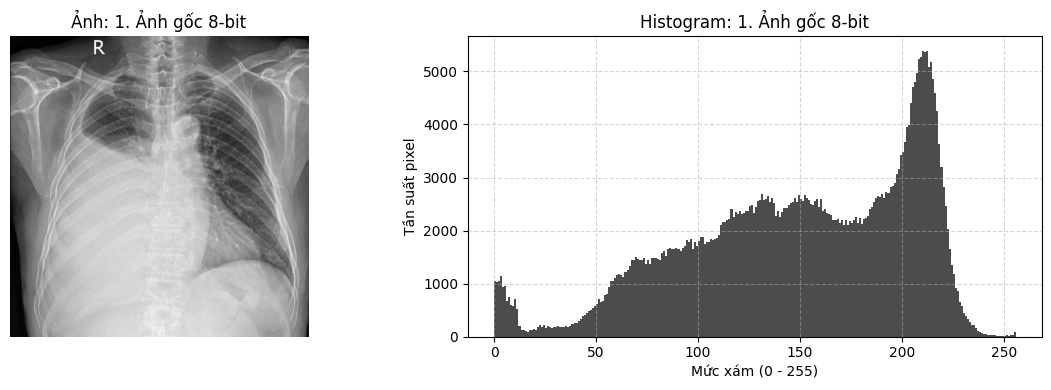

In [ ]:
# 1. ĐỌC ẢNH XÁM 8-BIT
# Sử dụng hàm cv2.imread với tham số cv2.IMREAD_GRAYSCALE để đọc ảnh từ Drive trực tiếp dưới dạng ảnh xám
original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# Kiểm tra điều kiện: xem biến original có bị rỗng (None) do sai đường dẫn hoặc file lỗi hay không
if original is None:
    # In ra thông báo lỗi kèm theo đường dẫn file nếu không đọc được ảnh
    print("Không đọc được ảnh:", image_path)
    # Dừng và thoát chương trình ngay lập tức để tránh các lỗi tính toán ở các bước sau
    raise SystemExit
print("--- 1. Đã nạp ảnh gốc ---")
# Gọi hàm show_step_result (đã định nghĩa ở ô code trước) để hiển thị ảnh gốc và biểu đồ Histogram
show_step_result("1. Ảnh gốc 8-bit", original)

--- 2. Đã khử nhiễu bằng Bilateral Filter ---


/tmp/ipykernel_1197/2981732479.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)


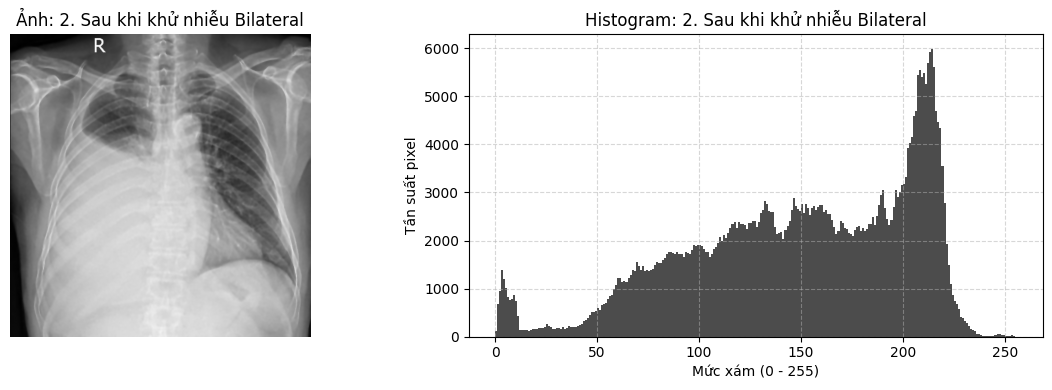

In [ ]:
# 2. KHỬ NHIỄU BẰNG BILATERAL FILTER
# Sử dụng bộ lọc Bilateral để làm mịn ảnh, giảm nhiễu hột nhưng vẫn giữ được độ sắc nét của các đường viền (rất quan trọng với ảnh X-quang)
denoised = cv2.bilateralFilter(
    original,       # Ảnh đầu vào cần khử nhiễu (ảnh gốc đã nạp ở bước 1)
    d=7,            # Đường kính của vùng lân cận điểm ảnh được sử dụng để lọc (7 là mức vừa phải, không làm máy chạy quá chậm)
    sigmaColor=35,  # Độ lệch chuẩn không gian màu: Giá trị 35 giúp các điểm ảnh có màu (mức xám) chênh lệch ít sẽ được hòa trộn để khử nhiễu
    sigmaSpace=35   # Độ lệch chuẩn không gian tọa độ: Giá trị 35 quy định mức độ ảnh hưởng của các pixel lân cận với pixel trung tâm
)
print("--- 2. Đã khử nhiễu bằng Bilateral Filter ---")
# Gọi hàm show_step_result để hiển thị ảnh sau khi khử nhiễu và so sánh với Histogram của ảnh gốc
show_step_result("2. Sau khi khử nhiễu Bilateral", denoised)

--- 3. Đã cân bằng tương phản bằng CLAHE ---


/tmp/ipykernel_1197/2981732479.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)


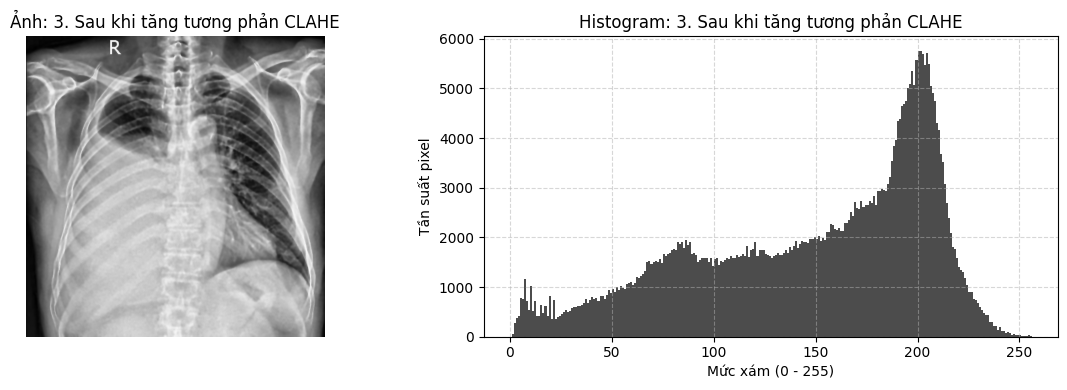

In [ ]:
# 3. TĂNG TƯƠNG PHẢN CỤC BỘ (CLAHE)
# Khởi tạo bộ lọc CLAHE (Cân bằng biểu đồ mức xám thích ứng có giới hạn)
clahe = cv2.createCLAHE(
    clipLimit=1.8,       # Đặt giới hạn độ tương phản (ngưỡng cắt). Giá trị 1.8 giúp tránh việc khuếch đại nhiễu quá mức ở các vùng đồng màu.
    tileGridSize=(8, 8)  # Chia ảnh thành lưới 8x8 (64 ô nhỏ). Thuật toán sẽ cân bằng tương phản riêng rẽ cho từng ô nhỏ này.
)
# Áp dụng đối tượng clahe vừa tạo lên bức ảnh đã khử nhiễu (denoised) từ bước 2
contrast = clahe.apply(denoised)

print("--- 3. Đã cân bằng tương phản bằng CLAHE ---")
# Gọi hàm hiển thị kết quả: Truyền vào tiêu đề và biến ảnh 'contrast' để xem sự thay đổi
show_step_result("3. Sau khi tăng tương phản CLAHE", contrast)

--- 4. Đã hiệu chỉnh Gamma & Unsharp Masking ---


/tmp/ipykernel_1197/2981732479.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)


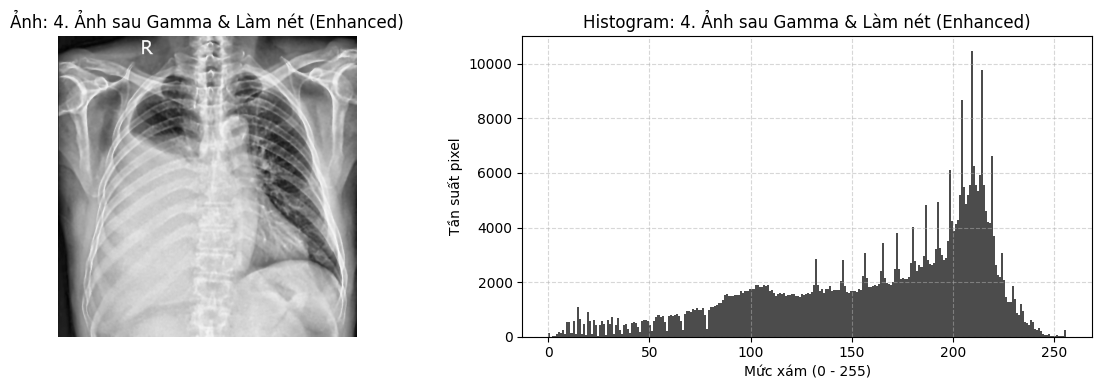

In [ ]:
# 4. HIỆU CHỈNH GAMMA VÀ UNSHARP MASKING
gamma = 1.25
# Tạo bảng tra cứu (LUT) tính sẵn công thức Gamma cho 256 mức xám để tăng tốc độ xử lý
gamma_table = np.array(
    [((v / 255.0) ** (1.0 / gamma)) * 255 for v in range(256)],
    dtype=np.uint8
)
# Áp dụng bảng LUT để làm sáng các vùng tối cục bộ trên ảnh
gamma_image = cv2.LUT(contrast, gamma_table)

# Làm mờ ảnh bằng Gaussian để lọc lấy các chi tiết khối lớn
blurred = cv2.GaussianBlur(gamma_image, (0, 0), sigmaX=1.1)
# Unsharp Masking: Trừ đi phần ảnh mờ để khuếch đại các chi tiết cạnh, làm ảnh sắc nét hơn
enhanced = cv2.addWeighted(gamma_image, 1.35, blurred, -0.35, 0)

print("--- 4. Đã hiệu chỉnh Gamma & Unsharp Masking ---")
show_step_result("4. Ảnh sau Gamma & Làm nét (Enhanced)", enhanced)

Chênh lệch sáng tương đối: 0.109
Chênh lệch trung bình (MAD): 34.2
--- 5. Đã tạo Bản đồ bất đối xứng (Heatmap) ---


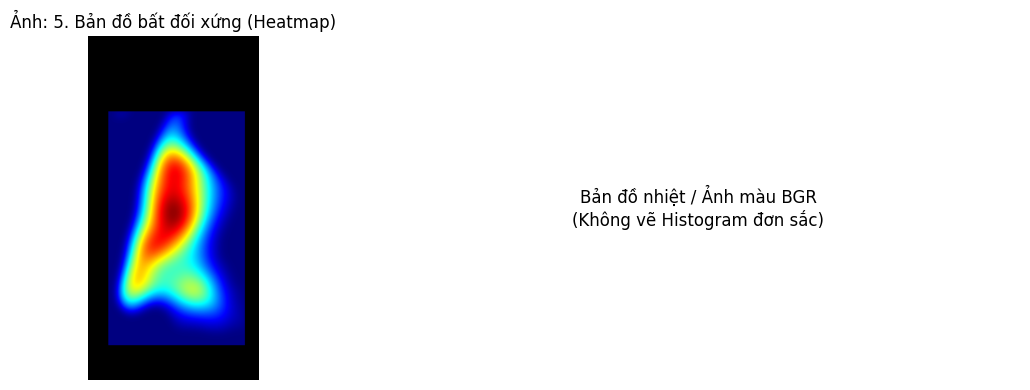

In [ ]:
# 5. TẠO BẢN ĐỒ BẤT ĐỐI XỨNG & TRỌNG SỐ DỌC

height, width = enhanced.shape
half_width = width // 2
# Lọc lấy các cấu trúc tần số thấp (khối lớn/tổng thể) bằng Gaussian Blur mạnh
low_frequency = cv2.GaussianBlur(
    enhanced,
    (0, 0),
    sigmaX=max(height, width) * 0.035
)
# Chia đôi ảnh và lật nửa phải để so sánh đối xứng giải phẫu 2 lá phổi
left = low_frequency[:, :half_width]
right = low_frequency[:, width - half_width:]
right_flipped = cv2.flip(right, 1)
# Đồng bộ kích thước hai nửa và chuyển sang float để tính toán số âm
compare_width = min(left.shape[1], right_flipped.shape[1])
left = left[:, :compare_width].astype(np.float32)
right_flipped = right_flipped[:, :compare_width].astype(np.float32)
# Tính ma trận chênh lệch giữa hai bán cầu phổi
difference = left - right_flipped
# Tạo vùng quan tâm (ROI) để loại bỏ nhiễu ở viền ngoài ảnh (khung xương, lề)
roi = np.zeros((height, compare_width), dtype=np.uint8)
roi[
    int(height * 0.22):int(height * 0.90),
    int(compare_width * 0.12):int(compare_width * 0.92)
] = 255
roi_pixels = roi > 0
# Tính toán các chỉ số chênh lệch sáng trung bình trong vùng ROI
mean_left = float(np.mean(left[roi_pixels]))
mean_right = float(np.mean(right_flipped[roi_pixels]))
mean_level = max((mean_left + mean_right) / 2.0, 1.0)
relative_difference = abs(mean_left - mean_right) / mean_level
mean_absolute_difference = float(np.mean(np.abs(difference[roi_pixels])))

print(f"Chênh lệch sáng tương đối: {round(relative_difference, 3)}")
print(f"Chênh lệch trung bình (MAD): {round(mean_absolute_difference, 1)}")

# Xác định bên phổi bất thường (bên sáng hơn có nguy cơ đọng dịch)
if mean_left >= mean_right:
    side_difference = difference
    abnormal_side = "left"
else:
    side_difference = -difference
    abnormal_side = "right"
# Áp dụng trọng số dọc: Tăng cường vùng đáy phổi (trọng số 1.35) vì dịch thường tụ ở dưới theo trọng lực
vertical_weight = np.linspace(0.65, 1.35, height, dtype=np.float32).reshape(-1, 1)
weighted_difference = np.maximum(side_difference, 0) * vertical_weight
weighted_difference[~roi_pixels] = 0
# Chuẩn hóa về [0-255], làm mượt và áp dụng dải màu Jet để tạo Bản đồ nhiệt (Heatmap)
difference_map = cv2.normalize(weighted_difference, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
difference_map = cv2.GaussianBlur(difference_map, (0, 0), sigmaX=7)
heatmap = cv2.applyColorMap(difference_map, cv2.COLORMAP_JET)
# Che đi (tô đen) các phần nằm ngoài vùng phân tích ROI
heatmap[roi == 0] = 0

print("--- 5. Đã tạo Bản đồ bất đối xứng (Heatmap) ---")
show_step_result("5. Bản đồ bất đối xứng (Heatmap)", heatmap, is_colormap=True)

Phát hiện chênh lệch lớn: Có tạo mặt nạ vùng chú ý.


/tmp/ipykernel_1197/2981732479.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black', alpha=0.7)


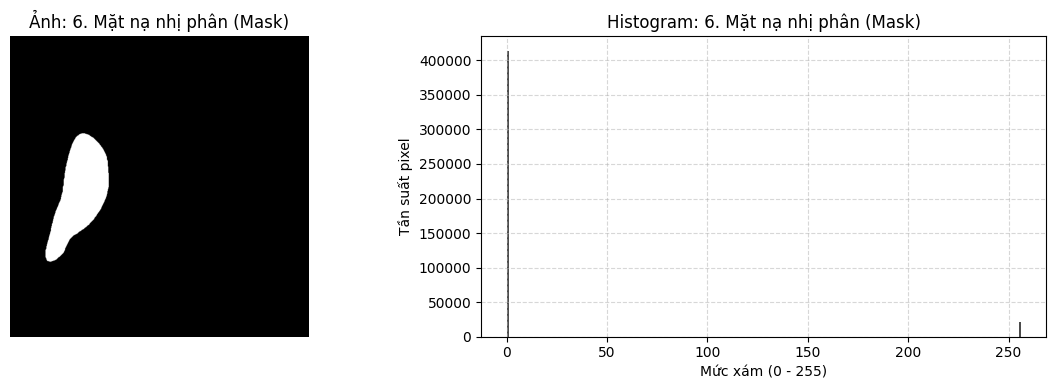

In [ ]:
# 6. PHÂN VÙNG MẶT NẠ VÀ XỬ LÝ HÌNH THÁI HỌC
# Khởi tạo mặt nạ đen bằng kích thước ảnh gốc
mask = np.zeros_like(original)

# Đánh giá mức độ bất đối xứng có vượt ngưỡng cảnh báo hay không
is_suspicious = (relative_difference >= MIN_RELATIVE_DIFFERENCE and mean_absolute_difference >= MIN_MEAN_DIFFERENCE)

if is_suspicious:
    # Lấy các pixel hợp lệ trong vùng ROI
    valid_values = weighted_difference[roi_pixels]
    # Lấy ngưỡng là phân vị thứ 82 (chỉ giữ lại 18% pixel sáng nhất, tương đương chênh lệch lớn nhất)
    threshold = max(18.0, float(np.percentile(valid_values, 82)))

    # Tạo mặt nạ nhị phân sơ bộ dựa trên ngưỡng threshold
    mask_half = np.zeros_like(roi)
    mask_half[(weighted_difference >= threshold) & roi_pixels] = 255

    # Khởi tạo các phần tử cấu trúc (kernel) hình elip
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

    # Phép CLOSE: Lấp đầy các lỗ hổng bên trong vùng khoanh vùng
    mask_half = cv2.morphologyEx(mask_half, cv2.MORPH_CLOSE, close_kernel)
    # Phép OPEN: Xóa bỏ các nhiễu rác nhỏ lấm tấm bên ngoài
    mask_half = cv2.morphologyEx(mask_half, cv2.MORPH_OPEN, open_kernel)

    # Tìm và đánh dấu các vùng liên thông (các đốm trắng tách biệt)
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask_half, connectivity=8)
    clean_mask_half = np.zeros_like(mask_half)

    # Nếu phát hiện đốm trắng (count > 1 do tính cả nền đen)
    if count > 1:
        # Lọc lấy đốm trắng có diện tích lớn nhất (vùng dịch lớn nhất)
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        largest_area = int(stats[largest_label, cv2.CC_STAT_AREA])

        # Giới hạn diện tích tối thiểu (chiếm ít nhất 2.5% vùng ROI)
        minimum_area = int(np.count_nonzero(roi) * 0.025)

        # Chỉ giữ lại vùng chọn nếu nó đủ lớn
        if largest_area >= minimum_area:
            clean_mask_half[labels == largest_label] = 255

            # Trả mặt nạ về đúng tọa độ của phổi trái hoặc phải trên ảnh gốc
            if abnormal_side == "left":
                mask[:, :compare_width] = clean_mask_half
            else:
                mask[:, width - compare_width:] = cv2.flip(clean_mask_half, 1)

    print("Phát hiện chênh lệch lớn: Có tạo mặt nạ vùng chú ý.")
else:
    # Hủy bỏ bản đồ nhiệt nếu không đủ điều kiện nghi ngờ
    heatmap[:] = 0
    print("Chênh lệch thấp: Không tạo mặt nạ vùng chú ý.")

show_step_result("6. Mặt nạ nhị phân (Mask)", mask)

--- 7. Đã hoàn thành kết quả cuối cùng ---


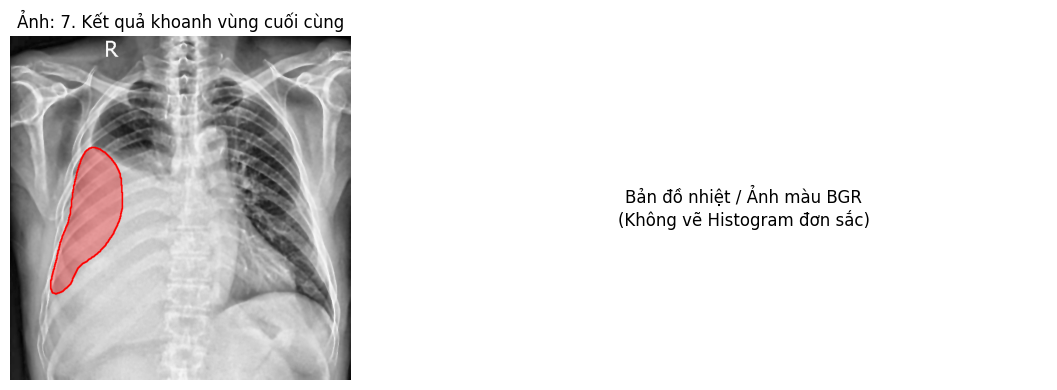

In [ ]:
# 7. TRỘN MÀU VÀ TẠO KẾT QUẢ CUỐI
# Chuyển ảnh xám (đã làm nét) sang hệ màu BGR để có thể vẽ lớp phủ màu đỏ lên trên
final_result = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

# Kiểm tra nếu mặt nạ có tồn tại vùng nghi ngờ tràn dịch (có điểm ảnh trắng)
if np.any(mask):
    # Tạo một bản sao để tô màu đỏ (0, 0, 255) vào vị trí của mặt nạ
    red_layer = final_result.copy()
    red_layer[mask > 0] = (0, 0, 255)

    # Trộn lớp màu đỏ (trọng số 0.3) với ảnh gốc (trọng số 0.7) để tạo hiệu ứng trong suốt
    final_result = cv2.addWeighted(final_result, 0.70, red_layer, 0.30, 0)

    # Tìm và vẽ đường viền (contour) nét liền màu đỏ đậm bao quanh vùng bất thường
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(final_result, contours, -1, (0, 0, 255), 2)

print("--- 7. Đã hoàn thành kết quả cuối cùng ---")
show_step_result("7. Kết quả khoanh vùng cuối cùng", final_result, is_colormap=True)


--- 8. HIỂN THỊ BẢNG TỔNG QUAN LƯỚI 3x2 ---


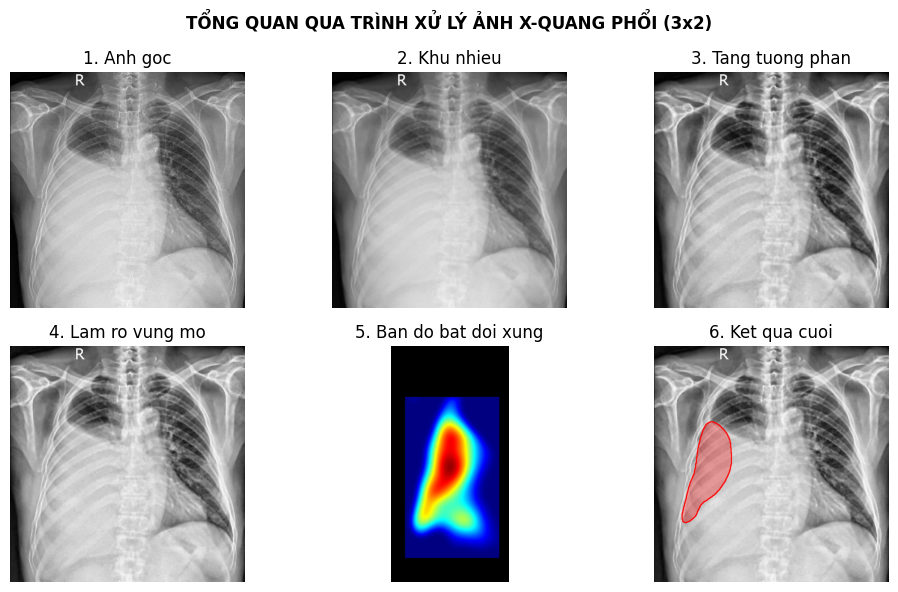

In [ ]:
# 8. HIỂN THỊ TỔNG QUAN LƯỚI 3x2 BẰNG MATPLOTLIB
print("\n--- 8. HIỂN THỊ BẢNG TỔNG QUAN LƯỚI 3x2 ---")

windows = [
    ("1. Anh goc", original, False),
    ("2. Khu nhieu", denoised, False),
    ("3. Tang tuong phan", contrast, False),
    ("4. Lam ro vung mo", enhanced, False),
    ("5. Ban do bat doi xung", heatmap, True),
    ("6. Ket qua cuoi", final_result, True),
]

plt.figure(figsize=(10, 6))
plt.suptitle("TỔNG QUAN QUA TRÌNH XỬ LÝ ẢNH X-QUANG PHỔI (3x2)", fontsize=12, fontweight='bold')

for index, (title, img, is_bgr) in enumerate(windows):
    plt.subplot(2, 3, index + 1)
    if is_bgr:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()